# Descripción del problema:

Aplicación web para simpificar la elección de proveedor en compras

Paso 1: Busca un conjunto de datos

In [21]:
import pandas as pd
from pandas import read_csv

In [22]:
# Carga de conjunto de datos

df = pd.read_csv("../data/raw/spend_analysis_dataset.csv")
df.head()

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
0,TXN001,Desk Chair,Furniture,10,113.15,1131.50,2024-04-19,TechMart Inc.,Kelly Joseph
1,TXN002,Stapler,Office Supplies,16,12.62,201.92,2024-07-06,CloudSoft Corp.,Kelly Joseph
2,TXN003,Annual Software License,Software,1,5649.34,5649.34,2024-09-10,TechMart Inc.,Kelly Joseph
3,TXN004,Notepad,Stationery,13,2.92,37.96,2024-01-21,FurniWorks Ltd.,Luis Holland
4,TXN005,Notepad,Stationery,19,1.39,26.41,2024-02-03,TechMart Inc.,Cynthia Jenkins


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  500 non-null    str    
 1   ItemName       500 non-null    str    
 2   Category       500 non-null    str    
 3   Quantity       500 non-null    int64  
 4   UnitPrice      500 non-null    float64
 5   TotalCost      500 non-null    float64
 6   PurchaseDate   500 non-null    str    
 7   Supplier       500 non-null    str    
 8   Buyer          500 non-null    str    
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


In [24]:
df = df.drop_duplicates()
df.shape

(500, 9)

<Axes: ylabel='ItemName'>

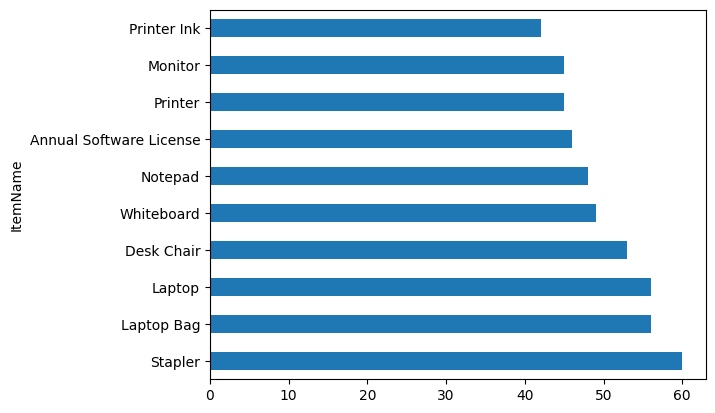

In [27]:
# Visualizar compras por item   
df['ItemName'].value_counts().head(10).plot(kind='barh')

<Axes: ylabel='Supplier'>

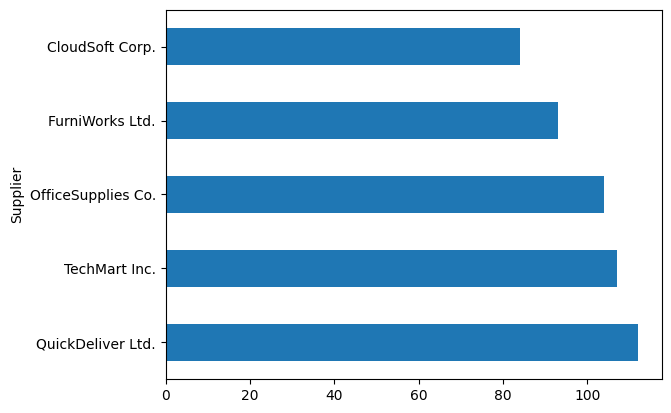

In [29]:
# Compras por proveedor 
df['Supplier'].value_counts().head(10).plot(kind='barh')

In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Definimios la función para asignar el proveedor óptimo basado en el precio mínimo

def asignar_proveedor_optimo(df):
    # 1. Encontrar el índice del precio mínimo para cada grupo de ItemName
    # idxmin() nos da la posición de la fila con el UnitPrice más bajo
    idx_min = df.groupby('ItemName')['UnitPrice'].idxmin()
    
    # 2. Creamos un diccionario mapeando: Articulo -> Proveedor con precio min
    # .loc[idx_min] extrae las filas ganadoras, luego creamos el mapa
    mapa_proveedores = df.loc[idx_min].set_index('ItemName')['Supplier'].to_dict()
    
    # 3. Creamos la nueva columna 'Proveedor_Elegido' basada en el mapa
    df['Proveedor_Elegido'] = df['ItemName'].map(mapa_proveedores)
    
    return df

df = asignar_proveedor_optimo(df)

# Verificación visual:
print(df[['ItemName', 'Supplier', 'UnitPrice', 'Proveedor_Elegido']].head(10))

                  ItemName            Supplier  UnitPrice   Proveedor_Elegido
0               Desk Chair       TechMart Inc.     113.15       TechMart Inc.
1                  Stapler     CloudSoft Corp.      12.62     CloudSoft Corp.
2  Annual Software License       TechMart Inc.    5649.34  OfficeSupplies Co.
3                  Notepad     FurniWorks Ltd.       2.92     CloudSoft Corp.
4                  Notepad       TechMart Inc.       1.39     CloudSoft Corp.
5                  Printer     FurniWorks Ltd.     150.94     FurniWorks Ltd.
6                  Notepad  OfficeSupplies Co.       2.73     CloudSoft Corp.
7                  Notepad     FurniWorks Ltd.       2.42     CloudSoft Corp.
8              Printer Ink     FurniWorks Ltd.      11.89     FurniWorks Ltd.
9               Whiteboard     FurniWorks Ltd.     100.82     FurniWorks Ltd.


Paso 2: Desarrolla un modelo

In [33]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 3. Preprocesamiento (Encoding)
le_item = LabelEncoder()
le_cat = LabelEncoder()
le_target = LabelEncoder()

# Preparamos las características (X) y el objetivo (y)
X = pd.DataFrame()
X['ItemName'] = le_item.fit_transform(df['ItemName'])
X['Category'] = le_cat.fit_transform(df['Category'])
y = le_target.fit_transform(df['Proveedor_Elegido'])

# 4. DIVISIÓN DEL CONJUNTO DE DATOS (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entrenar el Modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. EVALUACIÓN DEL MODELO
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Evaluación del Modelo ---")
print(f"Precisión (Accuracy): {accuracy * 100:.2f}%")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))



--- Evaluación del Modelo ---
Precisión (Accuracy): 100.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        14

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [35]:
# 7. Guardar archivos para Flask
joblib.dump(model, '../models/model.pkl')
joblib.dump(le_item, '../models/le_item.pkl')
joblib.dump(le_cat, '../models/le_cat.pkl')
joblib.dump(le_target, '../models/le_target.pkl')


['../models/le_target.pkl']